# Ángulos de Euler (ZYZ)

Este cuaderno muestra cómo construir la matriz de rotación a partir de ángulos de Euler (ZYZ) y cómo recuperar esos ángulos desde una matriz de rotación. Es útil para la enseñanza de rotaciones en 3D y para visualizar los efectos de las singularidades.

In [1]:
import numpy as np

In [ ]:
def dir_euler(angles):
    # Ángulos de Euler ZYZ: phi, theta, psi
    phi, theta, psi = angles

    # Rotación alrededor de Z (phi)
    Rz_phi = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi),  np.cos(phi), 0],
        [0,            0,           1]
    ])

    # Rotación alrededor de Y (theta)
    Ry_theta = np.array([
        [ np.cos(theta), 0, np.sin(theta)],
        [ 0,             1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])

    # Rotación alrededor de Z (psi)
    Rz_psi = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi),  np.cos(psi), 0],
        [0,            0,           1]
    ])

    return Rz_phi @ Ry_theta @ Rz_psi


In [ ]:
def inv_euler(R, conf, phi_singular=0.0):
    # conf = +1/-1 para elegir una de las dos soluciones posibles (duplicidad de Euler)
    s = np.sign(conf)

    theta = s * np.arccos(R[2, 2])

    # Tratamiento de la singularidad cuando theta == 0 o pi (gimbal lock)
    if np.isclose(abs(R[2,2]), 1.0, atol=1e-10):
        phi = phi_singular
        psi = np.arctan2(R[1, 0], R[0, 0]) - phi_singular
    else:
        phi = np.arctan2(s * R[1, 2], s * R[0, 2])
        psi = np.arctan2(s * R[2, 1], -s * R[2, 0])

    return np.array([phi, theta, psi])

In [ ]:
# Ejemplo: calculo de la matriz de rotación y recuperación de ángulos
angles = np.array([0.3, 0.5, 1.0])
R = dir_euler(angles)
print("Matriz de rotación\n", R)

# Recupero ángulos con configuración +
angles_rec = inv_euler(R, conf=1)
print(angles)
print("Angulos recuperados (conf=1):", angles_rec)

# Recupero ángulos con configuración -
angles_rec = inv_euler(R, conf=-1)
print(angles)
print("Angulos recuperados (conf=-1):", angles_rec)

# De las soluciones obtenidas vuelvo a calcular la matriz de rotación
R = dir_euler(angles_rec)

print("Matriz de rotación\n", R)


Matriz de rotación
 [[ 0.20431056 -0.86514828  0.45801271]
 [ 0.94401176  0.29794058  0.14167993]
 [-0.25903472  0.40342268  0.87758256]]
[0.3 0.5 1. ]
Angulos recuperados (conf=1): [0.3 0.5 1. ]
[0.3 0.5 1. ]
Angulos recuperados (conf=-1): [-2.84159265 -0.5        -2.14159265]
Matriz de rotación
 [[ 0.20431056 -0.86514828  0.45801271]
 [ 0.94401176  0.29794058  0.14167993]
 [-0.25903472  0.40342268  0.87758256]]


## Resultados en la singularidad (gimbal lock)

Cuando `theta` es 0 o π, las rotaciones alrededor de los ejes Z quedan alineadas y se pierde un grado de libertad (gimbal lock). En ese caso no hay una única solución para los ángulos de Euler y la función `inv_euler` necesita un valor de referencia (`phi_singular`) para fijar la rotación restante.

In [ ]:
# Ejemplo en la singularidad: theta = 0 (las dos rotaciones Z se alinean)
angles = np.array([0.3, 0, 1.0])
R = dir_euler(angles)
print("Matriz de rotación\n", R)


Matriz de rotación
 [[ 0.26749883 -0.96355819  0.        ]
 [ 0.96355819  0.26749883  0.        ]
 [ 0.          0.          1.        ]]


In [ ]:
# Recupero ángulos usando el valor por defecto de phi_singular = 0
angles_rec = inv_euler(R, conf=1)
print(angles)
print("Angulos recuperados (conf=1):", angles_rec)


[0.3 0.  1. ]
Angulos recuperados (conf=1): [0.  0.  1.3]


In [ ]:
# Fuerzo la solución usando phi_singular=0.3 para mostrar la libertad restante
angles_rec = inv_euler(R, conf=1, phi_singular=0.3)
print(angles)
print("Angulos recuperados (conf=1):", angles_rec)

[0.3 0.  1. ]
Angulos recuperados (conf=1): [0.3 0.  1. ]


## Ejercicio

Hallar las dos posibles soluciones de los ángulos de Euler ZYZ para expresar la orientación de la terna 3 según la 0

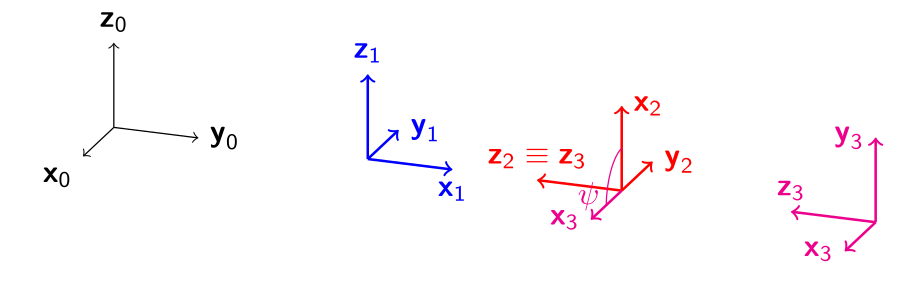

In [ ]:
# Construyo por inspección la matriz de rotación 
R = np.array([[1,0,0],[0,0,1],[0,-1,0]]).T
print(R)

[[ 1  0  0]
 [ 0  0 -1]
 [ 0  1  0]]


In [19]:
# Obtengo la solución 1 (theta positivo)
angles_rec = inv_euler(R, conf=1)
print("Solución con theta positivo",angles_rec)

# Obtengo la solución 1 (theta positivo)
angles_rec = inv_euler(R, conf=-1)
print("Solución con theta negativo",angles_rec)

# La solución del dibujo se corresponde con la negativa

Solución con theta positivo [-1.57079633  1.57079633  1.57079633]
Solución con theta negativo [ 1.57079633 -1.57079633 -1.57079633]
